### Deep Agents overview



Build agents that can plan, use subagents, and leverage file systems for complex tasks

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.


### When to use deep agents
Use deep agents when you need agents that can:

- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [1]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [2]:
from typing import Literal

In [3]:
### Tools- Internet search
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)



In [4]:
from langchain.chat_models import init_chat_model

model=init_chat_model("groq:openai/gpt-oss-20b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002254CE663C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002254CE670E0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

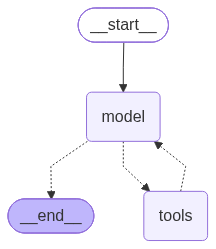

In [5]:
## Basic Agent
from langchain.agents import create_agent


simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

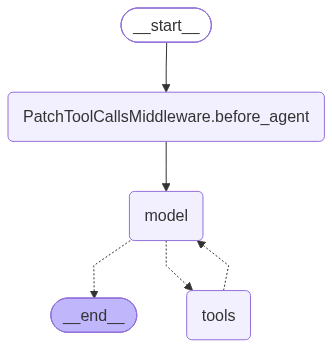

In [6]:
### Create a deep agent
## Prompt

## agent

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [7]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='2a623738-bed9-4f0d-af9b-a6c3c2db767b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is deepagent?" They might refer to a specific technology or concept. Could be "DeepAgent" as a deep learning-based agent? There\'s "DeepAgent" maybe a research paper or product. Or "Deep Agent" is a term used in AI. Let\'s search web.', 'tool_calls': [{'id': 'fc_28997ebd-2156-429f-b340-be5a49de7841', 'function': {'arguments': '{"max_results":5,"query":"deepagent","topic":"general"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 1743, 'total_tokens': 1840, 'completion_time': 0.104004822, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.101863516, 'prompt_tokens_details': None, 'queue_time': 0.332781145, 'total_time': 0.205868338}, 'model_name': 'openai/gpt-oss-

In [8]:
result["messages"][-1].content

'**DeepAgent** is a recent, research‑driven architecture for large‑language‑model (LLM) agents that unifies *thinking*, *tool discovery*, and *action execution* into a single, coherent reasoning loop.  \nIt was introduced in the paper **“DeepAgent: A General Reasoning Agent with Scalable Toolsets”** (accepted at WWW\u202f2026) and has since spawned an open‑source library (available on GitHub) that can be used with LangChain/LangGraph.\n\n---\n\n## 1. Core Idea\n\nTraditional agent frameworks (e.g., ReAct, AutoGPT, LangChain) follow a rigid cycle:  \n**Reason → Act → Observe → Reason**.  \nThe agent is given a fixed set of tools (API wrappers, functions, etc.) in the prompt, and it can only call those tools.\n\nDeepAgent replaces that cycle with a **single, end‑to‑end reasoning stream**:\n\n1. **Autonomous Thinking** – The LLM continuously reasons about the task, maintaining a global view of what has been done and what still needs to be achieved.\n2. **Dynamic Tool Discovery** – When th

In [9]:
result['files']

{}

### What happened?

Your deep agent automatically:
- Planned its approach: Used the built-in write_todos tool to break down the research task
- Conducted research: Called the internet_search tool to gather information
- Managed context: Used file system tools (write_file, read_file) to offload large search results
- Spawned subagents (if needed): Delegated complex subtasks to specialized subagents
- Synthesized a report: Compiled findings into a coherent response

### Customizing Deep Agents

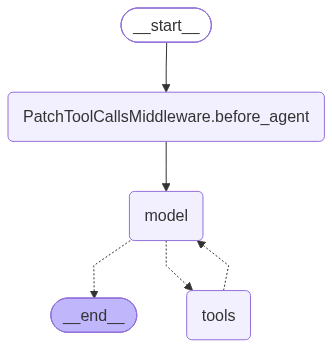

In [10]:
## #Model
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

model = init_chat_model("groq:openai/gpt-oss-20b")
agent = create_deep_agent(model=model)
agent

In [11]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='756d3647-e76a-42f6-9de0-fbc33e23bffc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is deepagent?" We need to answer. The system has no explicit knowledge. But maybe there\'s a file or concept in the repo. Let\'s search.', 'tool_calls': [{'id': 'fc_22ba2620-1705-422e-8ccf-df32ad031909', 'function': {'arguments': '{"path":"","pattern":"deepagent"}', 'name': 'glob'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 1671, 'total_tokens': 1736, 'completion_time': 0.06741301, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.102976666, 'prompt_tokens_details': None, 'queue_time': 0.261135528, 'total_time': 0.170389676}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'mod

### System Prompt
Deep agents come with a built-in system prompt inspired by Claude Code’s system prompt. The default system prompt contains detailed instructions for using the built-in planning tool, file system tools, and subagents.
Each deep agent tailored to a use case should include a custom system prompt specific to that use case.

In [13]:
from deepagents import create_deep_agent

research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='ceb3d29f-d9e9-47b6-b345-5f9d2c226c8b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to respond. The user asks "What is deepagent?" Likely they refer to DeepAgent, a product? We should search. Use grep to find references.', 'tool_calls': [{'id': 'fc_3fa6f7b3-6407-467b-ab83-4f029b9e8108', 'function': {'arguments': '{"output_mode":"files_with_matches","pattern":"deepagent"}', 'name': 'grep'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 1696, 'total_tokens': 1763, 'completion_time': 0.069188479, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.086164256, 'prompt_tokens_details': None, 'queue_time': 0.273462734, 'total_time': 0.155352735}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_84bb35977d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs

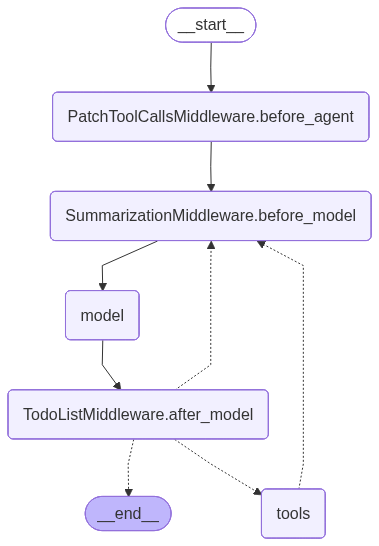

In [ ]:
agent

In [14]:
### Tools
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

agent = create_deep_agent(
    model=model,
    tools=[internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent in Agentic AI?"}]})
result

{'messages': [HumanMessage(content='What is deepagent in Agentic AI?', additional_kwargs={}, response_metadata={}, id='81c97c10-618c-4efc-97fb-607af74b7d4a'),
  AIMessage(content='**DeepAgent in Agentic AI**\n\nIn the context of *Agentic AI*—the study of artificial agents that act, reason, and learn autonomously—**DeepAgent** refers to a particular class of agents that combine two key ideas:\n\n| Feature | What it means | Why it matters |\n|---------|---------------|----------------|\n| **Deep Learning backbone** | The agent’s perception, decision‑making, and policy modules are built using deep neural networks (CNNs, RNNs, Transformers, etc.). | Enables handling high‑dimensional inputs (images, speech, raw sensor data) and learning complex, non‑linear mappings. |\n| **Agentic architecture** | The agent is structured around *goal‑driven* or *intentional* components: a planner, a belief‑state updater, a value function, or a policy that can be conditioned on goals and constraints. | Gives